In [88]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta, norm

from sequence import simulate_sequences  

In [337]:
# PARAMETERS
params = {
    "n_neurons": 100,
    "n_motifs": 20,
    "n_bins": 100,
    "n_sequences": 100,
    "sigma_range": (0.02,0.4),    # increasing range makes sequences less similar
    "vol_param": (0.07, 0.2),     # beta distribution:  0.07, 0.9
                                  # a inactive (lower -> more neurons inactive, if high longer seqs, mean len shifts)
                                  # b active (lower -> more neurons active, if <1, skewed to 1, if lower longer seqs, mean len shifts)
    "corr_mu": False,
    "rho_mu": 0.0,
    "corr_sigma": False,
    "rho_sig": 0.0,
    "corr_volume": False,
    "rho_vol": 0.0,
    "shuffle_order": False,       # shuffle order of sequences

}

In [ ]:

seqs, seqs_labels, spk_times, sequences, true_templates, mu, sigma, volume, densities, cdfs = simulate_sequences(**params, random_state=2, plot=True)

## Changing Volume Parameters

### Sequence Length Across All Motifs

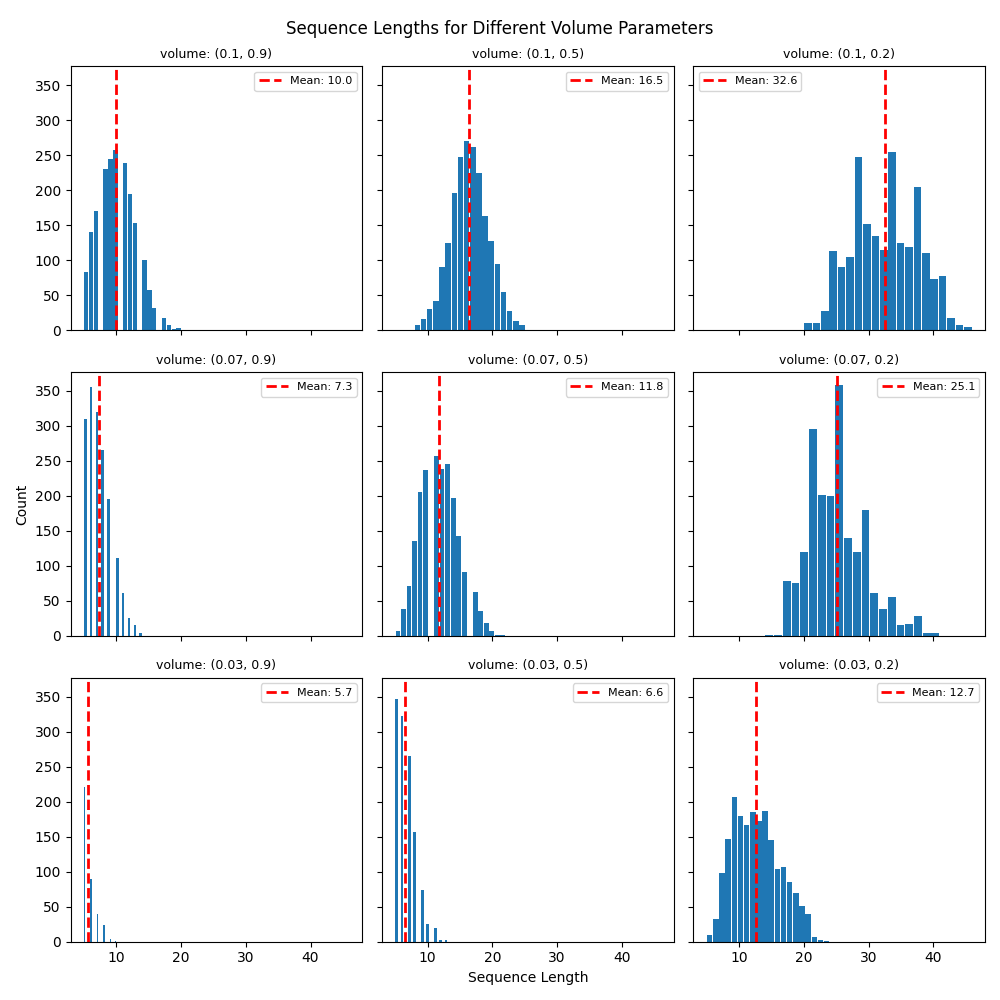

In [339]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10), sharey=True, sharex=True)
fig.suptitle("Sequence Lengths for Different Volume Parameters", fontsize=12)

vol_upper = [0.9, 0.5, 0.2]
vol_lower = [0.1, 0.07, 0.03]

mean_lengths = np.zeros((len(vol_lower), len(vol_upper)))

for row, v_low in enumerate(vol_lower):
    for col, v_high in enumerate(vol_upper):
        lengths = []
        params["vol_param"] = (v_low, v_high)
        seqs_tmp, *_ = simulate_sequences(**params, random_state=2, plot=False)
        lengths = [len(seq) for seq in seqs_tmp]
        mean_lengths[row, col] = np.mean(lengths)

        axes[row, col].hist(lengths, bins=20, rwidth=0.9)
        axes[row, col].axvline(mean_lengths[row, col], color='red', linestyle='dashed', linewidth=2, label=f"Mean: {mean_lengths[row, col]:.1f}")
        axes[row, col].legend(fontsize=8)
        axes[2, 1].set_xlabel('Sequence Length')
        axes[1, 0].set_ylabel('Count')
        axes[row, col].set_title(f'volume: {params["vol_param"]}', fontsize=9)

plt.tight_layout()
plt.show()

### Sequence Length per Motif (keep volume constant)

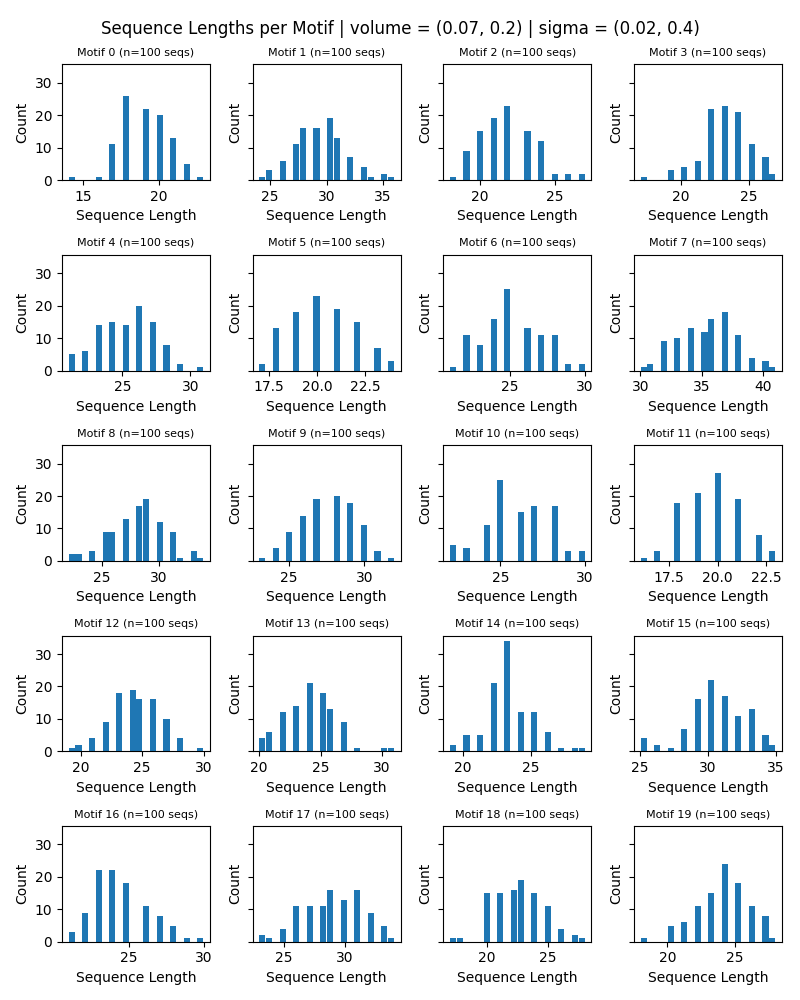

In [342]:
n_motifs = params["n_motifs"]
n_neurons = params["n_neurons"]
n_cols = 4
n_rows = int(np.ceil(n_motifs / n_cols))
params["vol_param"] = (0.07, 0.2)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows), sharey=True)
fig.suptitle(f"Sequence Lengths per Motif | volume = {params['vol_param']} | sigma = {params['sigma_range']}", fontsize=12)

for motif in range(n_motifs):
    motif_sequences = [seqs[i] for i, lbl in enumerate(seqs_labels) if lbl == motif]
    lengths = [len(seq) for seq in motif_sequences]
    ax = axes[motif // n_cols, motif % n_cols]
    ax.hist(lengths, bins=20, rwidth=0.9)
    ax.set_title(f"Motif {motif} (n={len(motif_sequences)} seqs)", fontsize=8)
    ax.set_xlabel("Sequence Length")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Sequence Length per Motif (keep lower volume bound constant)

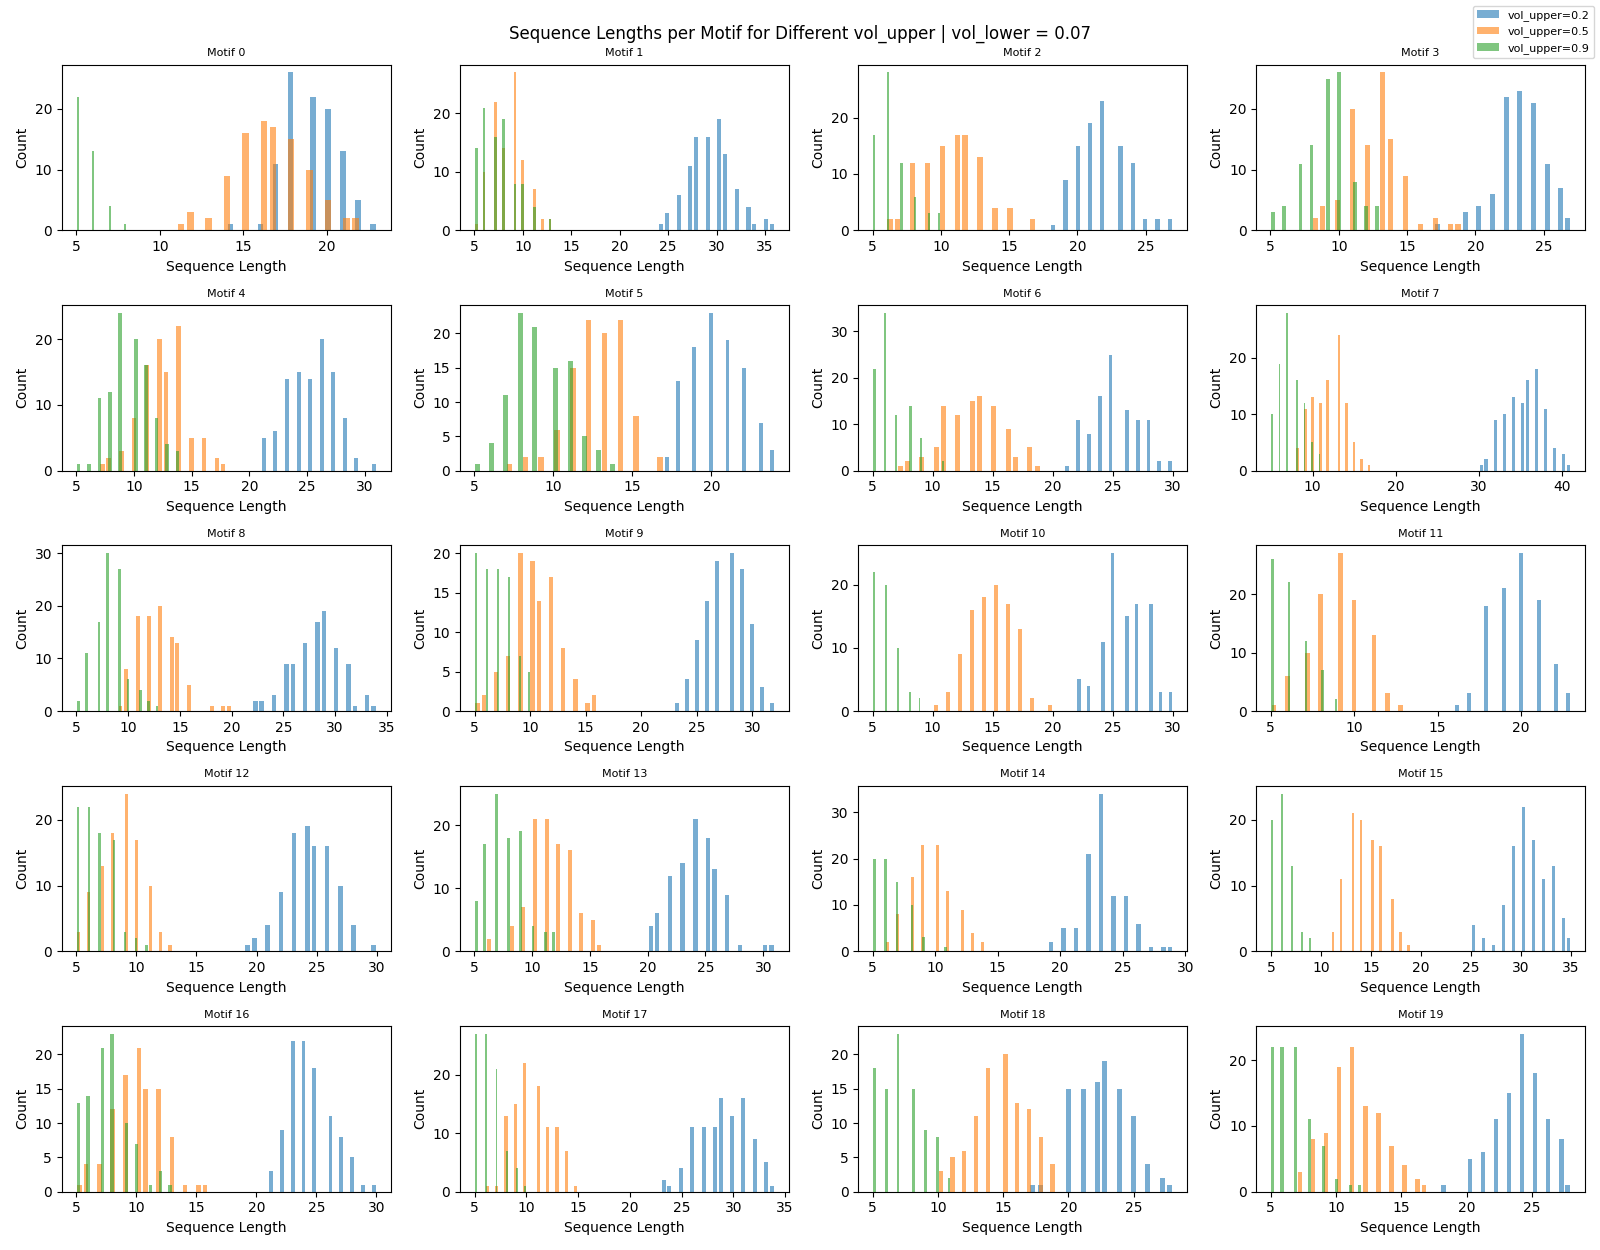

In [344]:
vol_upper = [0.2, 0.5, 0.9]
vol_lower = 0.07  # keep lower fixed

n_motifs = params["n_motifs"]
n_neurons = params["n_neurons"]
n_cols = 4
n_rows = int(np.ceil(n_motifs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 2.5 * n_rows))
fig.suptitle(f"Sequence Lengths per Motif for Different vol_upper | vol_lower = {vol_lower}", fontsize=12)

colors = ['tab:blue', 'tab:orange', 'tab:green']

# Store legend handles and labels
legend_handles = []
legend_labels = []

for i, v_high in enumerate(vol_upper):
    legend_labels.append(f"vol_upper={v_high}")

for motif in range(n_motifs):
    ax = axes[motif // n_cols, motif % n_cols]
    for i, v_high in enumerate(vol_upper):
        params["vol_param"] = (vol_lower, v_high)
        seqs_tmp, seqs_labels_tmp, *_ = simulate_sequences(**params, random_state=2, plot=False)
        motif_sequences = [seqs_tmp[j] for j, lbl in enumerate(seqs_labels_tmp) if lbl == motif]
        lengths = [len(seq) for seq in motif_sequences]
        n, bins, patches = ax.hist(lengths, bins=20, rwidth=0.7, color=colors[i], alpha=0.6)
        if motif == 0:
            legend_handles.append(patches[0])
    ax.set_title(f"Motif {motif}", fontsize=8)
    ax.set_xlabel("Sequence Length")
    ax.set_ylabel("Count")

# Add one legend for the whole figure
fig.legend(legend_handles, legend_labels, loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

### Active Neuron Counts per Motif, Sorted (volume and sigma are constant)

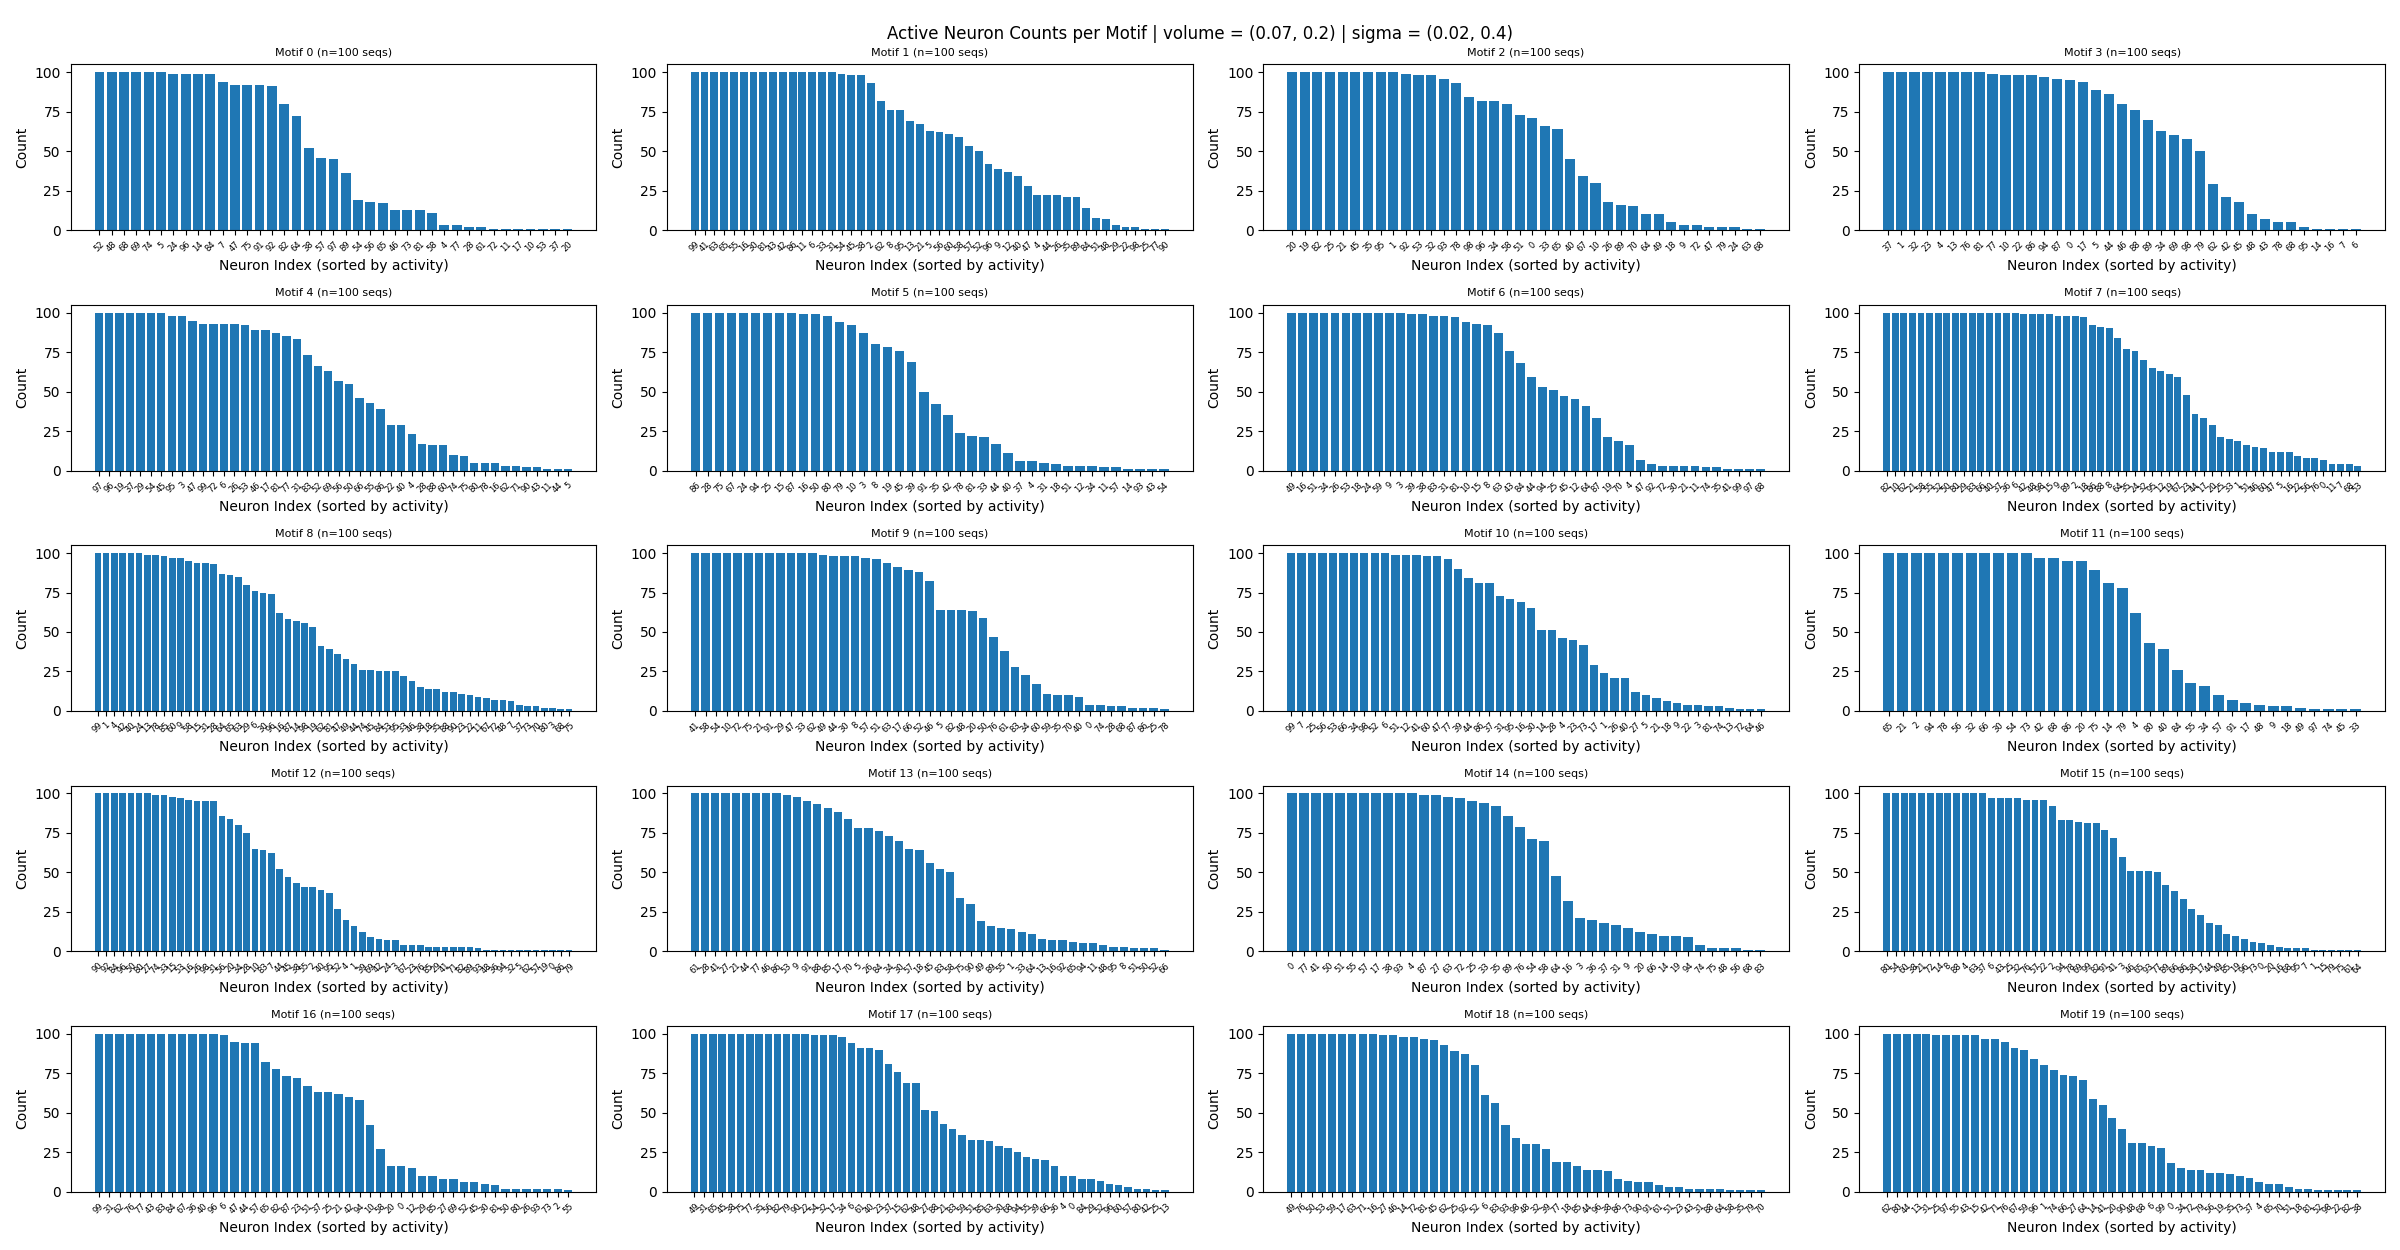

In [340]:
# Sort neuron indeces  from last plot based on counts for each motif and plot again:
%matplotlib widget
n_motifs = params["n_motifs"]
n_neurons = params["n_neurons"]
params["vol_param"] = (0.07, 0.2)  # reset to original for this plot
n_cols = 4
n_rows = int(np.ceil(n_motifs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 2.5 * n_rows))
fig.suptitle(f"Active Neuron Counts per Motif | volume = {params['vol_param']} | sigma = {params['sigma_range']}", fontsize=12)

for motif in range(n_motifs):
    motif_sequences = [seqs[i] for i, lbl in enumerate(seqs_labels) if lbl == motif]

    active_counts = np.zeros(n_neurons, dtype=int)
    for seq in motif_sequences:
        if len(seq) > 0:
            active_counts[np.asarray(seq, dtype=int)] += 1

    # Sort neuron indices by their counts (descending)
    sorted_indices = np.argsort(active_counts)[::-1]
    sorted_counts = active_counts[sorted_indices]

    # Only plot nonzero counts
    nonzero = sorted_counts > 0

    ax = axes[motif // n_cols, motif % n_cols]
    ax.bar(np.arange(np.sum(nonzero)), sorted_counts[nonzero])
    ax.set_xticks(np.arange(np.sum(nonzero)))
    ax.set_xticklabels(sorted_indices[nonzero], rotation=45, fontsize=6)
    ax.set_title(f"Motif {motif} (n={len(motif_sequences)} seqs)", fontsize=8)
    ax.set_xlabel("Neuron Index (sorted by activity)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
# number of actived neurons across sequences for each motif

def motif_neuron_counts(n_motifs, seqs, seqs_labels, n_neurons):
    counts = np.zeros((n_motifs, n_neurons), dtype=int)
    for motif in range(n_motifs):
        motif_sequences = [seqs[i] for i, lbl in enumerate(seqs_labels) if lbl == motif]
        for seq in motif_sequences:
            if len(seq) > 0:
                counts[motif, np.asarray(seq, dtype=int)] += 1
    return counts

motif_counts = motif_neuron_counts(params["n_motifs"], seqs, seqs_labels, params["n_neurons"])

 # which neurons are active for each motif (set of neuron indices)

def neuron_idx_motif(n_motifs, seqs, seqs_labels):
    motif_neuron_idx = {motif: set() for motif in range(n_motifs)}
    for motif in range(n_motifs):
        motif_sequences = [seqs[i] for i, lbl in enumerate(seqs_labels) if lbl == motif]
        for seq in motif_sequences:
            if len(seq) > 0:
                motif_neuron_idx[motif].update(np.asarray(seq, dtype=int))
    return motif_neuron_idx

neuron_idx_motif = neuron_idx_motif(params["n_motifs"], seqs, seqs_labels)


### Active Neuron Counts per Motif with Changing Volume Upper Bound, sorted to vol_upper = 0

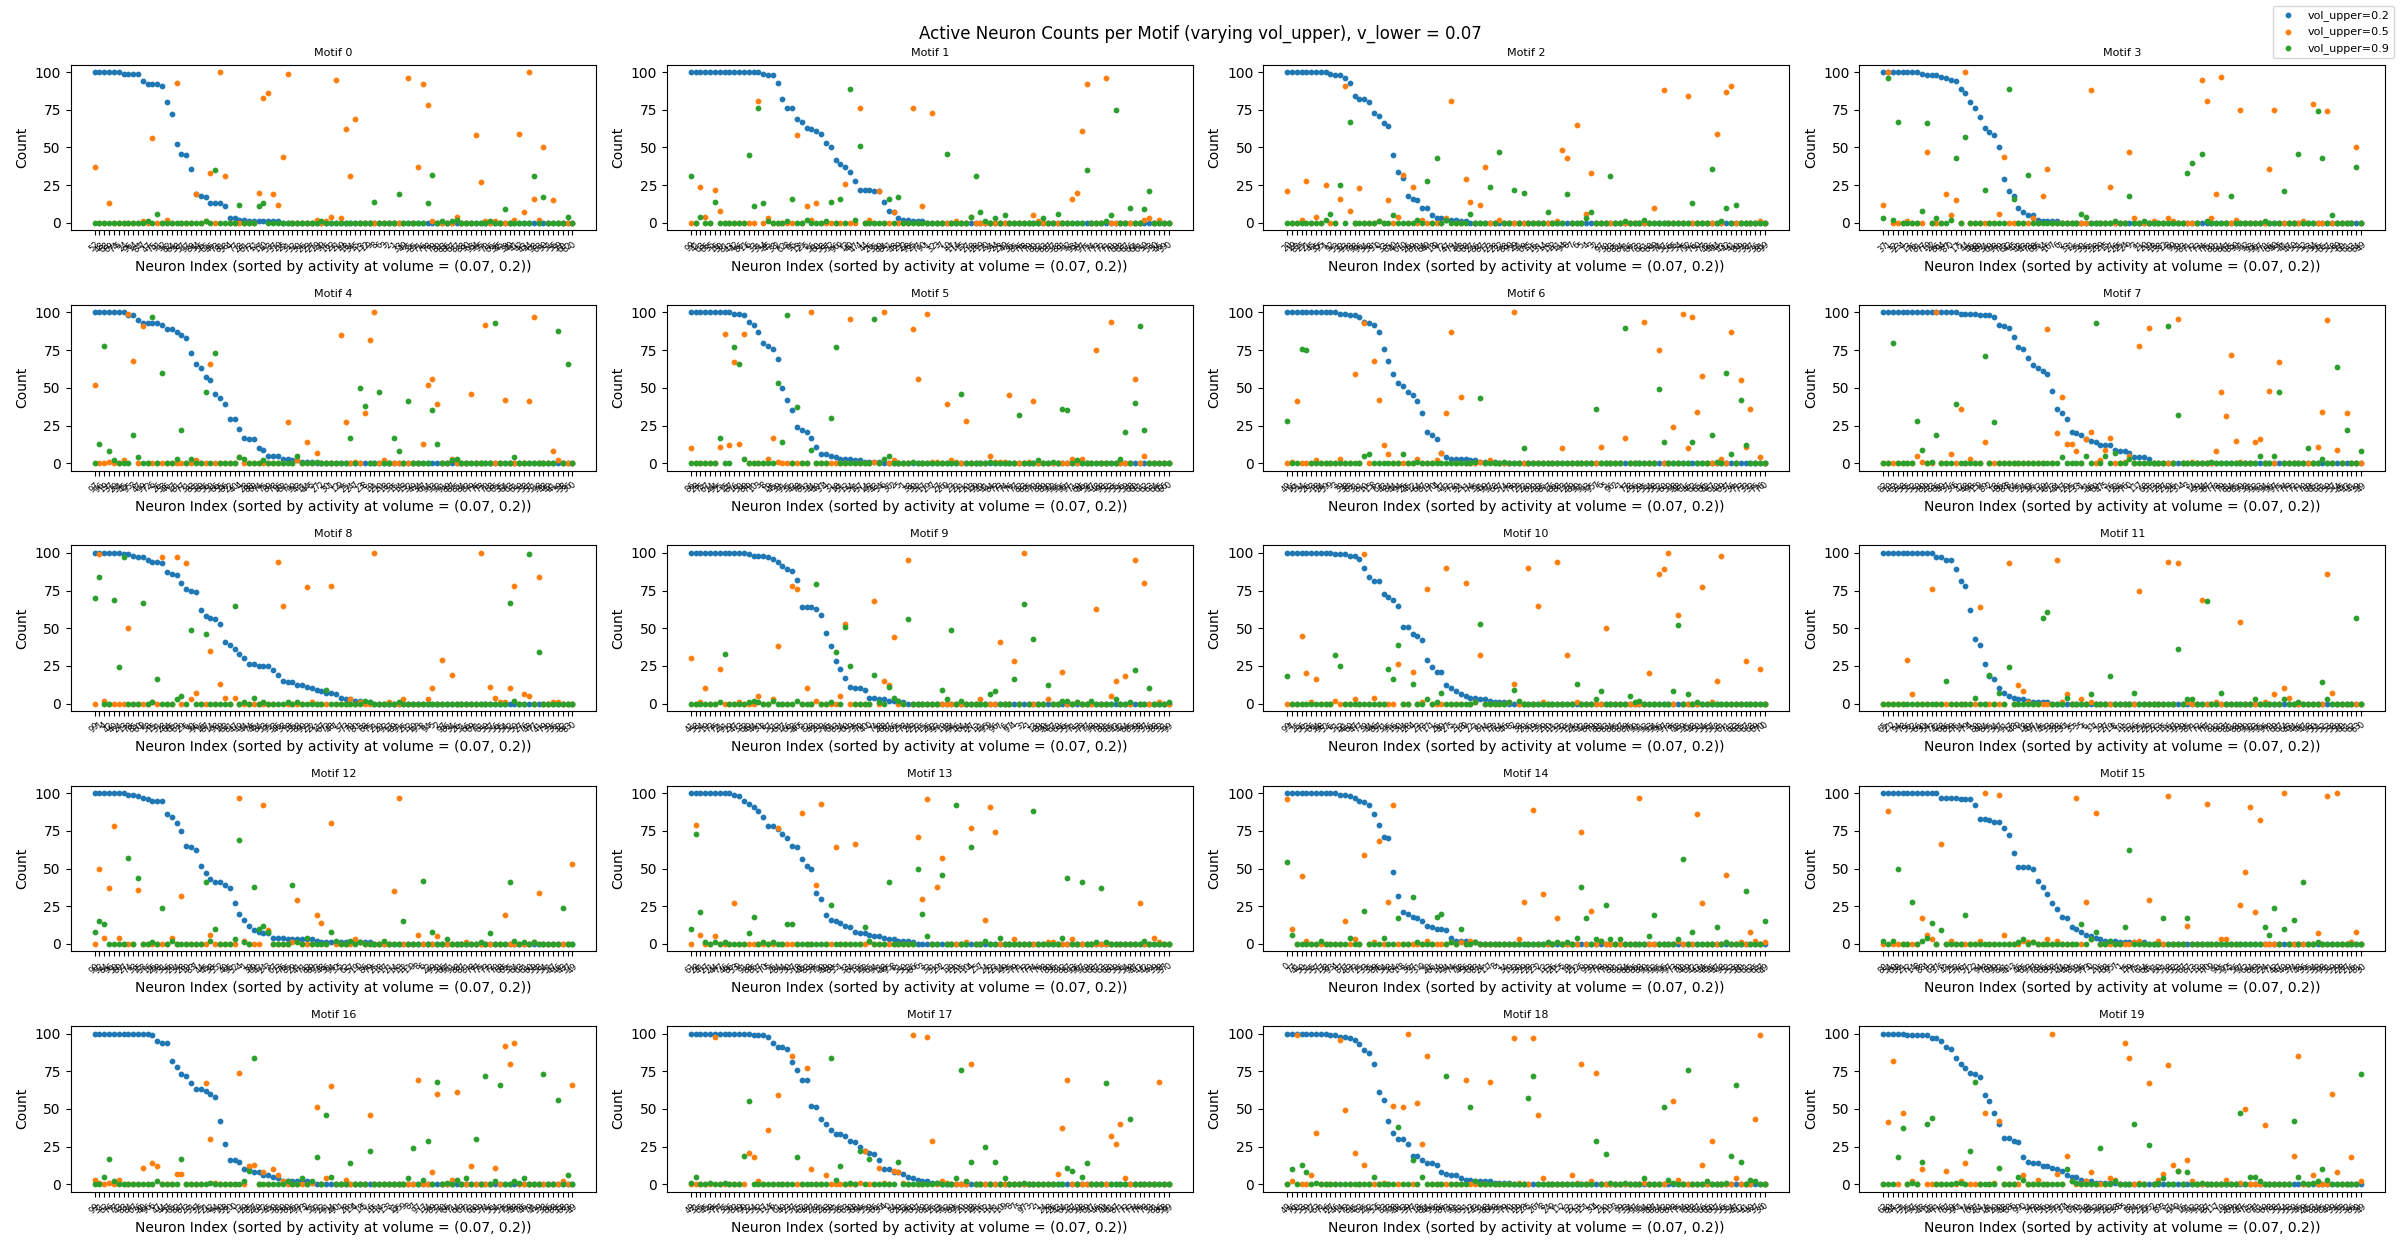

In [336]:
%matplotlib widget
vol_upper = [0.2, 0.5, 0.9]
vol_lower = 0.07 # keep lower fixed

n_motifs = params["n_motifs"]
n_neurons = params["n_neurons"]
n_cols = 4
n_rows = int(np.ceil(n_motifs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 2.5 * n_rows))
fig.suptitle("Active Neuron Counts per Motif (varying vol_upper), v_lower = 0.07", fontsize=12)
axes = np.atleast_2d(axes)

legend_handles = []
legend_labels = []

for motif in range(n_motifs):
    active_counts_per_vol = []
    sorted_indices_0_2 = None
    for v_high in vol_upper:
        params["vol_param"] = (vol_lower, v_high)
        seqs, seqs_labels, *_ = simulate_sequences(**params, random_state=2, plot=False)
        motif_sequences = [seqs[i] for i, lbl in enumerate(seqs_labels) if lbl == motif]
        active_counts = np.zeros(n_neurons, dtype=int)
        for seq in motif_sequences:
            if len(seq) > 0:
                active_counts[np.asarray(seq, dtype=int)] += 1
        active_counts_per_vol.append(active_counts)
        
        if v_high == 0.2:
            # Filter indices: keep only those with nonzero in any vol_upper
            # active_counts_per_vol_tmp = np.array(active_counts_per_vol)
            # nonzero_any = np.any(active_counts_per_vol_tmp > 0, axis=0)
            sorted_indices_0_2 = np.argsort(active_counts)[::-1]
            # sorted_indices_0_2 = sorted_indices_0_2[nonzero_any[sorted_indices_0_2]]
    active_counts_per_vol = np.array(active_counts_per_vol)
    # Use sorted_indices_0_2 for x axis

    ax = axes[motif // n_cols, motif % n_cols]
    for i, v_high in enumerate(vol_upper):
        sorted_counts = active_counts_per_vol[i][sorted_indices_0_2]
        scatter = ax.scatter(np.arange(len(sorted_indices_0_2)), sorted_counts, label=f"vol_upper={v_high}", s=10)
        if motif == 0:
            legend_handles.append(scatter)
            legend_labels.append(f"vol_upper={v_high}")
    ax.set_xticks(np.arange(len(sorted_indices_0_2)))
    ax.set_xticklabels(sorted_indices_0_2, rotation=45, fontsize=6)
    ax.set_title(f"Motif {motif}", fontsize=8)
    ax.set_xlabel("Neuron Index (sorted by activity at volume = (0.07, 0.2))")
    ax.set_ylabel("Count")

fig.legend(legend_handles, legend_labels, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## Changing Sigma Parameters

## Others

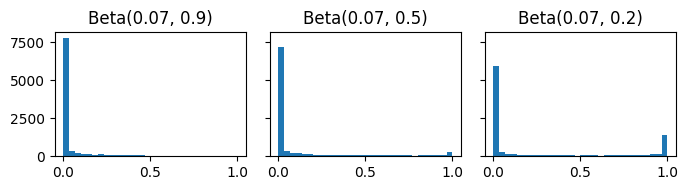

In [91]:
vol_samples1 = np.random.beta(0.07, 0.9, 10000)
vol_samples2 = np.random.beta(0.07, 0.5, 10000)
vol_samples3 = np.random.beta(0.07, 0.2, 10000) 

fig, axes = plt.subplots(1, 3, figsize=(7, 2), sharey=True)
    
axes[0].hist(vol_samples1, bins=30)
axes[0].set_title("Beta(0.07, 0.9)")

axes[1].hist(vol_samples2, bins=30)
axes[1].set_title("Beta(0.07, 0.5)")

axes[2].hist(vol_samples3, bins=30)
axes[2].set_title("Beta(0.07, 0.2)")

plt.tight_layout()
plt.show()
